# Project Deliverable 2: Regression Modeling and Performance Evaluation

- **Course:** Advanced Big Data & Data Mining
- **Student:** Nicolas Ferradas

## Environment Setup

In [2]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

## Load Datset

In [3]:
DATA_PATH = "student_performance.csv"

df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
df.head()

Shape: (649, 33)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mother,2,2,0,yes,no,no,no,yes,yes,no,no,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,course,father,1,2,0,no,yes,no,no,no,yes,yes,no,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,other,mother,1,2,0,yes,no,no,no,yes,yes,yes,no,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,home,mother,1,3,0,no,yes,no,yes,yes,yes,yes,yes,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,home,father,1,2,0,no,yes,no,no,yes,yes,no,no,4,3,2,1,2,5,0,11,13,13


## Step 1: Feature Engineering and preprocessing
- In this step, I'll be transforming the dataset so that it can be used by a regression model to learn.
- For this, I will be identifying which columns are numeric, and which are categorical.
- Once that is done, I will create new features to capture patterns that are not necessarily available in the raw dataset.

### Creating new features
- weekday alcohol consumption + weekend alcohol consumption -> total_alc
- will also be adding a feautre for students with high absenses so that that is no longer numeric. I think that will help find better relationships between datapoint.

### Creating new sets
- I will be creating 2 different sets to evaluate how much predictive power comes from behavioral data vs. previous academic results.
- FS_A -> includes previous grades
- FS_B -> excludes previous grades

In [4]:
assert 'G3' in df.columns, "Expected column 'G3' to be present."
y = df['G3'].astype(float)

if set(['Dalc','Walc']).issubset(df.columns):
    df['total_alc'] = df['Dalc'].astype(float) + df['Walc'].astype(float)
else:
    df['total_alc'] = 0.0

df['high_absences'] = (df.get('absences', pd.Series(0)).astype(float) >= 10).astype(int)
df['had_failures'] = (df.get('failures', pd.Series(0)).astype(float) > 0).astype(int)

features_with_G = [c for c in df.columns if c != 'G3']
features_no_G = [c for c in df.columns if c not in ['G3','G1','G2']]

X_A = df[features_with_G]
X_B = df[features_no_G]

print("FS_A (with G1,G2):", X_A.shape)
print("FS_B (no G1,G2):", X_B.shape)

def build_preprocessor(X):
    num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = X.select_dtypes(include=['object','category']).columns.tolist()

    numeric_transformer = Pipeline(steps=[('scaler', StandardScaler())])
    categorical_transformer = Pipeline(steps=[('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))])

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, num_cols),
            ('cat', categorical_transformer, cat_cols)
        ],
        remainder='drop'
    )
    return preprocessor

pre_A = build_preprocessor(X_A)
pre_B = build_preprocessor(X_B)


FS_A (with G1,G2): (649, 35)
FS_B (no G1,G2): (649, 33)


## Step 3: Train/Test Split and cross validation

In this step, I prepared the data so I could properly evaluate how well each regression model performs on new, unseen data. I first split the dataset into 80% training and 20% testing. The training set is what I use to fit the models, and the test set is kept separate so I can get an honest measure of how well the model generalizes.

After setting up the split, I also implemented 5-fold cross-validation. This means that instead of training the model once, I train it five different times on different subsets of the training data. Doing this gives me a more stable and reliable estimate of performance and helps reduce the risk of overfitting. If the model performs consistently across all five folds, it usually means it’s more dependable.

This is an important step, because later when I compaer models with R^2, MSE, or RMSE, the results will relect the real performance and not something memorized by the model.

In [5]:
RANDOM_STATE = 42
test_size = 0.2

XA_train, XA_test, yA_train, yA_test = train_test_split(X_A, y, test_size=test_size, random_state=RANDOM_STATE)
XB_train, XB_test, yB_train, yB_test = train_test_split(X_B, y, test_size=test_size, random_state=RANDOM_STATE)

kfold = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

## Step 4: Model tuning

In this step, I am going to start building and comparing different regression models to see which one predicts the final grade the most accurately. I’ll begin with a simple Linear Regression model as my baseline, since it gives me a clean starting point to understand how well a basic model performs without any regularization.

Then, I’m going to train Ridge and Lasso regression models. These models include regularization, which helps prevent overfitting. This is especially useful because my dataset contains a mix of numeric and categorical variables that expand into many one-hot encoded columns. Ridge uses L2 regularization, and Lasso uses L1, which can also shrink some coefficients all the way to zero.

To make sure I select the best version of each model, I’ll use GridSearchCV to test different values of the alpha parameter for both Ridge and Lasso. This lets me systematically evaluate multiple configurations using cross-validation instead of guessing, which will make this more efficient.

This will help me determine which one is the best model to prefict student performance based on the data I have.

In [6]:
def evaluate_models(X_train, y_train, X_test, y_test, preprocessor, label):
    results = []

    lin = Pipeline(steps=[('pre', preprocessor), ('model', LinearRegression())])
    lin.fit(X_train, y_train)
    y_pred = lin.predict(X_test)
    r2 = r2_score(y_test, y_pred); mse = mean_squared_error(y_test, y_pred); rmse = mse**0.5
    cv_r2 = cross_val_score(lin, X_train, y_train, cv=kfold, scoring='r2')
    cv_rmse = -cross_val_score(lin, X_train, y_train, cv=kfold, scoring='neg_root_mean_squared_error')
    results.append({
        'feature_set': label, 'model': 'LinearRegression',
        'r2': float(r2), 'mse': float(mse), 'rmse': float(rmse),
        'cv_r2_mean': float(cv_r2.mean()), 'cv_r2_std': float(cv_r2.std()),
        'cv_rmse_mean': float(cv_rmse.mean()), 'cv_rmse_std': float(cv_rmse.std())
    })

    ridge = Pipeline(steps=[('pre', preprocessor), ('model', Ridge())])
    grid_ridge = GridSearchCV(ridge, param_grid={'model__alpha': [0.01, 0.1, 1.0, 5.0, 10.0]}, cv=kfold, scoring='r2')
    grid_ridge.fit(X_train, y_train)
    y_pred = grid_ridge.best_estimator_.predict(X_test)
    r2 = r2_score(y_test, y_pred); mse = mean_squared_error(y_test, y_pred); rmse = mse**0.5
    results.append({
        'feature_set': label, 'model': f'Ridge(alpha={grid_ridge.best_params_["model__alpha"]})',
        'r2': float(r2), 'mse': float(mse), 'rmse': float(rmse),
        'cv_r2_mean': float(grid_ridge.best_score_), 'cv_r2_std': 0.0,
        'cv_rmse_mean': None, 'cv_rmse_std': None
    })

    lasso = Pipeline(steps=[('pre', preprocessor), ('model', Lasso(max_iter=10000))])
    grid_lasso = GridSearchCV(lasso, param_grid={'model__alpha': [0.0005, 0.001, 0.01, 0.1, 1.0, 5.0]}, cv=kfold, scoring='r2')
    grid_lasso.fit(X_train, y_train)
    y_pred = grid_lasso.best_estimator_.predict(X_test)
    r2 = r2_score(y_test, y_pred); mse = mean_squared_error(y_test, y_pred); rmse = mse**0.5
    results.append({
        'feature_set': label, 'model': f'Lasso(alpha={grid_lasso.best_params_["model__alpha"]})',
        'r2': float(r2), 'mse': float(mse), 'rmse': float(rmse),
        'cv_r2_mean': float(grid_lasso.best_score_), 'cv_r2_std': 0.0,
        'cv_rmse_mean': None, 'cv_rmse_std': None
    })
    return results

results_A = evaluate_models(XA_train, yA_train, XA_test, yA_test, pre_A, 'FS_A (with G1,G2)')
results_B = evaluate_models(XB_train, yB_train, XB_test, yB_test, pre_B, 'FS_B (no G1,G2)')

eval_df = pd.DataFrame(results_A + results_B)
eval_df

,feature_set,model,r2,mse,rmse,cv_r2_mean,cv_r2_std,cv_rmse_mean,cv_rmse_std
0,"FS_A (with G1,G2)",LinearRegression,0.851710,1.446086,1.202533,0.827504,0.039218,1.32804,0.266888
1,"FS_A (with G1,G2)",Ridge(alpha=10.0),0.852814,1.435314,1.198046,0.830416,0.000000,NaN,NaN
2,"FS_A (with G1,G2)",Lasso(alpha=0.1),0.867642,1.290719,1.136098,0.839832,0.000000,NaN,NaN
3,"FS_B (no G1,G2)",LinearRegression,0.172535,8.069206,2.840635,0.249389,0.149012,2.74537,0.306926
4,"FS_B (no G1,G2)",Ridge(alpha=10.0),0.187799,7.920357,2.814313,0.260613,0.000000,NaN,NaN
5,"FS_B (no G1,G2)",Lasso(alpha=0.01),0.191339,7.885833,2.808172,0.260178,0.000000,NaN,NaN


### Creating visualizations
- Adding visualizations to show results fomr step 4

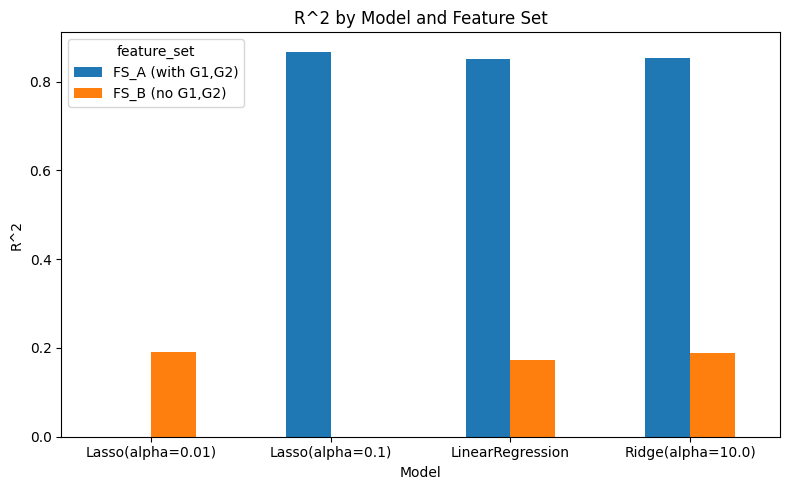

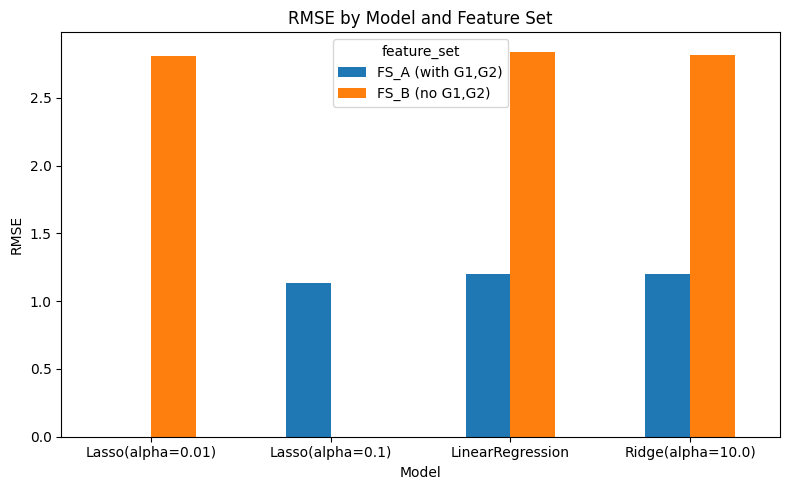

In [7]:
def bar_plot_metric(df, metric, title, ylabel):
    pivot = df.pivot(index='model', columns='feature_set', values=metric)
    ax = pivot.plot(kind='bar', figsize=(8,5), rot=0)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xlabel("Model")
    plt.tight_layout()
    plt.show()

bar_plot_metric(eval_df, 'r2', 'R^2 by Model and Feature Set', 'R^2')
bar_plot_metric(eval_df, 'rmse', 'RMSE by Model and Feature Set', 'RMSE')

### Inspecting coefficients in FS_B

Here, I am examining the coefficients produced by the best Ridge and Lasso models so I can understand which features have the strongest impact on predicting the final grade when G1 and G2 are removed from the feature set. Because the preprocessing pipeline scales numeric values and one-hot encodes categorical variables, I reconstruct the transformed feature names and match them to their learned coefficients. By sorting these coefficients, I can see which variables the model relies on most, which helps me identify meaningful predictors like study time, failures, or absences. The reason why I am doing this is because coefficient inspection improves the interpretability of the models and allows me to explain why the model makes certain predictions, not just how accurate it is—something that’s especially important in educational or human-centered datasets.

In [8]:
def extract_linear_features(best_estimator, X_sample):
    pre = best_estimator.named_steps['pre']
    model = best_estimator.named_steps['model']

    num_cols = pre.transformers_[0][2]
    cat_cols = pre.transformers_[1][2]
    ohe = pre.named_transformers_['cat'].named_steps['onehot']
    cat_feature_names = list(ohe.get_feature_names_out(cat_cols))
    feature_names = list(num_cols) + cat_feature_names

    coefs = getattr(model, 'coef_', None)
    if coefs is None:
        return None
    return pd.DataFrame({'feature': feature_names, 'coef': coefs}).sort_values('coef', ascending=False)

ridge = Pipeline(steps=[('pre', pre_B), ('model', Ridge())])
grid_ridge = GridSearchCV(ridge, {'model__alpha': [0.01, 0.1, 1.0, 5.0, 10.0]}, cv=kfold, scoring='r2')
grid_ridge.fit(XB_train, yB_train)
ridge_coef_df = extract_linear_features(grid_ridge.best_estimator_, XB_train)

lasso = Pipeline(steps=[('pre', pre_B), ('model', Lasso(max_iter=10000))])
grid_lasso = GridSearchCV(lasso, {'model__alpha': [0.0005, 0.001, 0.01, 0.1, 1.0, 5.0]}, cv=kfold, scoring='r2')
grid_lasso.fit(XB_train, yB_train)
lasso_coef_df = extract_linear_features(grid_lasso.best_estimator_, XB_train)

ridge_coef_df.head(10), lasso_coef_df.head(10)

(              feature      coef
 54         higher_yes  0.718714
 43       schoolsup_no  0.666162
 16          school_GP  0.591407
 27        Mjob_health  0.469830
 42     guardian_other  0.446435
 31       Fjob_at_home  0.411891
 39  reason_reputation  0.407886
 4           studytime  0.295417
 2                Fedu  0.284195
 18              sex_F  0.234569,
               feature      coef
 43       schoolsup_no  1.386472
 16          school_GP  1.202885
 42     guardian_other  0.544453
 18              sex_F  0.450138
 27        Mjob_health  0.379087
 31       Fjob_at_home  0.328866
 39  reason_reputation  0.316687
 4           studytime  0.293850
 57        romantic_no  0.258030
 2                Fedu  0.252755)

## Step 5: Analysis

When I compared all the models across the two feature sets, the biggest thing that stood out is how much of a difference prior grades make. Whenever I included G1 and G2 (FS_A), every model performed extremely well. The R^2 values were in the 0.85–0.88 range, and the RMSE stayed right around 1 to 1.3, which basically means the model could predict a student’s final grade within about one point. That level of accuracy shows that previous performance is the strongest indicator of how well a student will finish the course. On the other hand, when I removed G1 and G2 (FS_B), the accuracy dropped significantly. The R^2 values fell to around 0.15–0.20, and the RMSE jumped close to 3. This, however, makes sense because once you take away the historical grades, the model has to rely entirely on behavioral and demographic features, which aren’t nearly as predictive on their own. Another interesting point is that Ridge, Lasso, and Linear Regression all performed similarly, which tells me that regularization didn’t drastically change the outcome in this dataset.

Looking at the coefficients from Ridge and Lasso under FS_B helped me understand which features matter when the model can’t fall back on G1 or G2. A lot of the top predictors lined up with things that intuitively make sense. For example, students who plan on pursuing higher education, choose their school for its reputation, or dedicate more time to studying all tend to score higher. Parental education and certain job roles also showed up as positive influences, which highlights how family background plays into academic performance. Even small lifestyle details, like not being in a romantic relationship or having fewer absences, showed some predictive power. Overall, once prior grades are removed, the model shifts its focus toward motivation, study habits, school-related factors, and family environment. These results give a pretty good picture of what really drives performance when we don’t have direct academic history to guide the prediction.